<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/supervised/ES04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Provide an archive containing the report and the developed code to obtain the best performance on the full dataset provided:

BOW parameters should be tuned by you (image size, grid size, number of centroids, number of training images).
The maximum number of training images is 70, since the last 30 have to be used for testing
You can also experiment with a different classifier instead of the 1-NN provided, but it is more important to experiment with BOW parameters
Provide in the report the best parameter configuration obtained, the final accuracy, the confusion matrix, and a short comment about the type of classification errors that your model is doing

In [1]:
import os
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from google.colab import drive


In [2]:
# load the dataset
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/Supervised/ES04/image.orig_minimal.zip


In [4]:
 #---- PARAMETERS: TBD
featStep = 50
imsize = 500
Nim4training = 7 # fixed to 70 on the complete dataset
K = 100

In [5]:
# grid creation
pointPositions = np.array([[float(ii), float(jj)]
                           for ii in range(featStep, imsize-featStep, featStep)
                           for jj in range(featStep, imsize-featStep, featStep)])
print(f'Total points: {len(pointPositions)}')

Total points: 64


In [6]:
# feature extraction
features = []
labels = []
sift = cv2.SIFT_create()

start_time = time.time()

for class_idx in range(3):
  for nimage in range(Nim4training):
    img_path = f'./image.orig_minimal/{100*class_idx + nimage}.jpg'
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (imsize, imsize))
    keypoints = [cv2.KeyPoint(x, y, 1) for x, y in pointPositions]
    keypoints, descriptors = sift.compute(img, keypoints)
    features.append(descriptors)
    labels.append(np.column_stack((np.full(len(descriptors), class_idx),
                                   np.full(len(descriptors), nimage))))

print(f'Feature extraction completed in {time.time() - start_time:.2f}')

features = np.vstack(features)
labels = np.vstack(labels)

Feature extraction completed in 0.29


In [7]:
features.shape, labels.shape

((1344, 128), (1344, 2))

In [8]:
labels

array([[0, 0],
       [0, 0],
       [0, 0],
       ...,
       [2, 6],
       [2, 6],
       [2, 6]])

In [10]:
# kmeans clustering
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10) # ----> TBD
# train the kmeans model
start_time = time.time()
kmeans.fit(features)
IDX = kmeans.fit_predict(features)
C = kmeans.cluster_centers_
print(f'Kmeans clustering completed in {time.time() - start_time:.2f}')


Kmeans clustering completed in 4.44


In [ ]:
C.shape, IDX.shape

((100, 128), (1728,))

In [11]:
# BOW histograms for training images
BOW_tr = []
labels_tr = []

for class_idx in range(3):
  for nimage in range(Nim4training):
    u = np.where((labels[:,0] == class_idx) & (labels[:,1] == nimage))[0]
    imfeaturesIDX = IDX[u]
    H, _ = np.histogram(imfeaturesIDX, bins=np.arange(K+1), density=True)
    BOW_tr.append(H)
    labels_tr.append(class_idx)
BOW_tr = np.array(BOW_tr)
labels_tr = np.array(labels_tr)


In [16]:
# BOW histograms for testing images
BOW_te = []
labels_te = []

for class_idx in range(3):
  for nimage in range(Nim4training, 10):
    img_path = f'./image.orig_minimal/{100*class_idx + nimage}.jpg'
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (imsize, imsize))
    keypoints = [cv2.KeyPoint(x, y, 1) for x, y in pointPositions]
    keypoints, descriptors = sift.compute(img, keypoints)

    D = np.linalg.norm(descriptors[:, np.newaxis] -C, axis=2)
    words = np.argmin(D, axis=1)
    H, _ = np.histogram(words, bins=np.arange(K+1), density=True)
    BOW_te.append(H)
    labels_te.append(class_idx)

BOW_te = np.array(BOW_te)
labels_te = np.array(labels_te)

In [19]:
BOW_tr.shape, labels_tr.shape, BOW_te.shape, labels_te.shape

((21, 100), (21,), (9, 100), (9,))

In [17]:
# classification ----> TBD
predicted_class = []

for H in BOW_te:
  distances = np.linalg.norm(BOW_tr - H, axis=1)
  u = np.argmin(distances)
  predicted_class.append(labels_tr[u])

predicted_class = np.array(predicted_class)

In [18]:
predicted_class

array([0, 0, 0, 2, 1, 1, 2, 2, 2])

Accuracy: 0.67


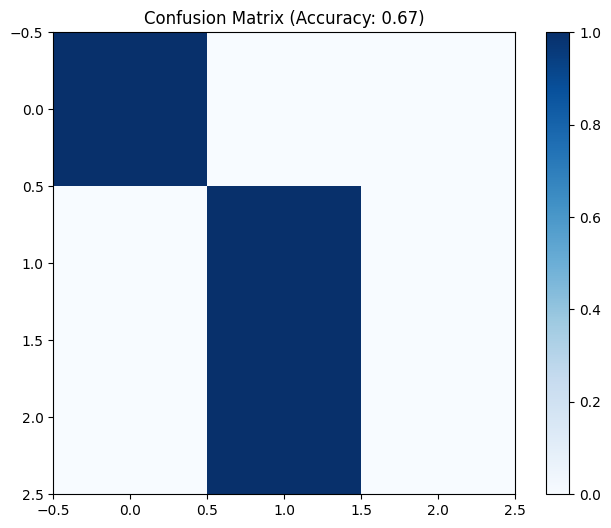

In [ ]:
# performance measurement
CM = confusion_matrix(labels_te, predicted_class, normalize='true')
accuracy = np.mean(np.diag(CM))

print(f'Accuracy: {accuracy:.2f}')
plt.figure(figsize=(8,6))
plt.imshow(CM, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2f})')
plt.show()

#Tune parameters
on the entire dataset

In [ ]:
!unzip /content/drive/MyDrive/Supervised/CNN/SimplicityDB.zip

In [4]:
def with_tune_param(featStep=8, imsize=64, Nim4training=70, ks=20, num_class=2):

  # grid creation
  pointPositions = np.array([[float(ii), float(jj)]
                           for ii in range(featStep, imsize-featStep, featStep)
                           for jj in range(featStep, imsize-featStep, featStep)])

  # feature extraction
  features = []
  labels = []
  sift = cv2.SIFT_create()

  start_time = time.time()

  for class_idx in range(num_class):
    train_dir = f'SimplicityDB/train/{class_idx}'
    image_list = sorted(os.listdir(train_dir))[:Nim4training]
    for nimage, img_name in enumerate(image_list):
      img_path = os.path.join(train_dir, img_name)
      img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
      img = cv2.resize(img, (imsize, imsize))
      keypoints = [cv2.KeyPoint(x, y, 1) for x, y in pointPositions]
      keypoints, descriptors = sift.compute(img, keypoints)
      features.append(descriptors)
      labels.append(np.column_stack((np.full(len(descriptors), class_idx),
                                    np.full(len(descriptors), nimage))))

  print(f'Feature extraction completed in {time.time() - start_time:.2f}')
  features = np.vstack(features)
  labels = np.vstack(labels)

  # kmeans clustering
  kmeans = KMeans(n_clusters=ks, random_state=42, n_init=10)
  start_time = time.time()
  IDX = kmeans.fit_predict(features)
  C = kmeans.cluster_centers_
  print(f'Kmeans clustering completed in {time.time() - start_time:.2f}')

  # BOW histograms for training images
  BOW_tr = []
  labels_tr = []

  for class_idx in range(num_class):
    for nimage in range(Nim4training):
      u = np.where((labels[:,0] == class_idx) & (labels[:,1] == nimage))[0]
      imfeaturesIDX = IDX[u]
      H, _ = np.histogram(imfeaturesIDX, bins=np.arange(ks+1), density=True)
      BOW_tr.append(H)
      labels_tr.append(class_idx)
  BOW_tr = np.array(BOW_tr)
  labels_tr = np.array(labels_tr)

  # BOW histograms for testing images
  BOW_te = []
  labels_te = []

  for class_idx in range(num_class):
    test_dir = f'SimplicityDB/test/{class_idx}'
    image_list = sorted(os.listdir(test_dir))[:Nim4training]
    for nimage, img_name in enumerate(image_list):
      img_path = os.path.join(test_dir, img_name)
      img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
      img = cv2.resize(img, (imsize, imsize))
      keypoints = [cv2.KeyPoint(x, y, 1) for x, y in pointPositions]
      keypoints, descriptors = sift.compute(img, keypoints)

      D = np.linalg.norm(descriptors[:, np.newaxis] -C, axis=2)
      words = np.argmin(D, axis=1)
      H, _ = np.histogram(words, bins=np.arange(ks+1), density=True)
      BOW_te.append(H)
      labels_te.append(class_idx)

  BOW_te = np.array(BOW_te)
  labels_te = np.array(labels_te)

  # classification ----> TBD
  predicted_class = []

  for H in BOW_te:
    distances = np.linalg.norm(BOW_tr - H, axis=1)
    u = np.argmin(distances)
    predicted_class.append(labels_tr[u])

  predicted_class = np.array(predicted_class)

  # performance measurement
  CM = confusion_matrix(labels_te, predicted_class, normalize='true')
  accuracy = np.mean(np.diag(CM))

  print(f'Accuracy: {accuracy:.2f}')
  plt.figure(figsize=(8,6))
  plt.imshow(CM, cmap='Blues', interpolation='nearest')
  plt.colorbar()
  plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2f})')
  plt.show()

Feature extraction completed in 0.07
Kmeans clustering completed in 0.16
Accuracy: 0.50


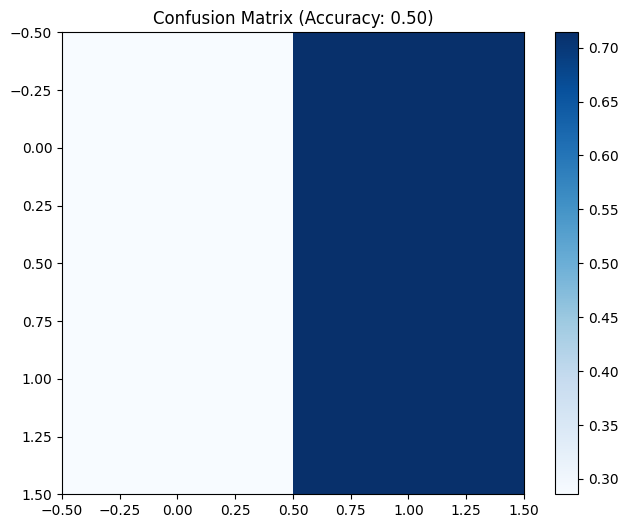

In [5]:
with_tune_param(featStep=8, imsize=64, Nim4training=7, ks=20, num_class=2)

Feature extraction completed in 0.05
Kmeans clustering completed in 0.27
Accuracy: 0.43


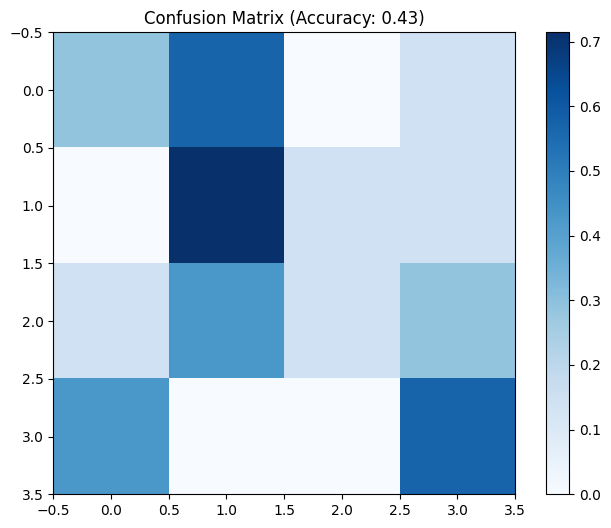

In [6]:
with_tune_param(featStep=8, imsize=64, Nim4training=7, ks=20, num_class=4)


Feature extraction completed in 0.04
Kmeans clustering completed in 0.13
Accuracy: 0.33


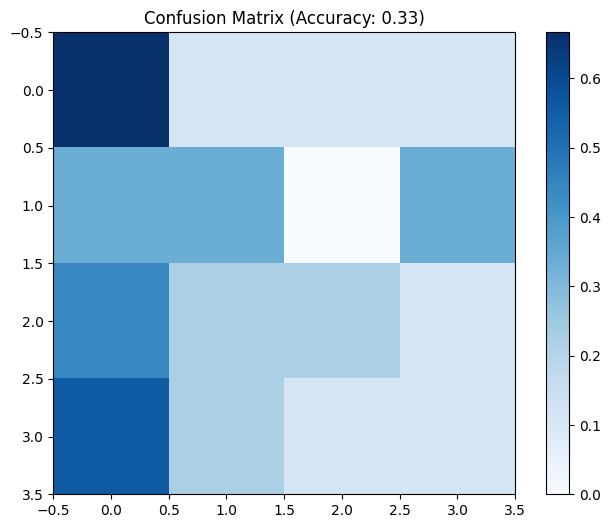

In [7]:
with_tune_param(featStep=20, imsize=64, Nim4training=9, ks=40, num_class=4)


Feature extraction completed in 0.12
Kmeans clustering completed in 1.76
Accuracy: 0.50


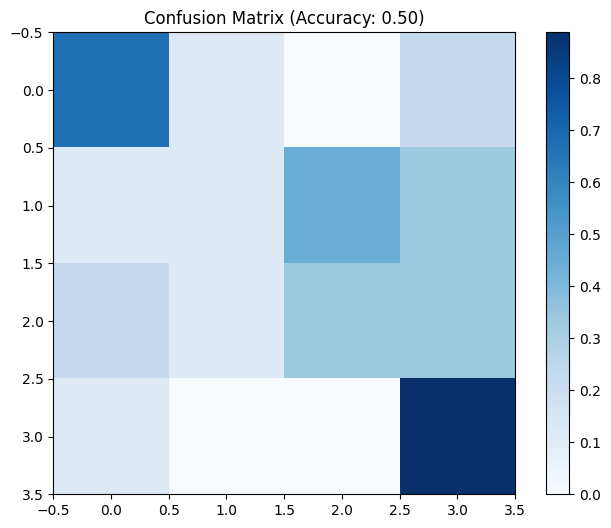

In [8]:
with_tune_param(featStep=20, imsize=255, Nim4training=9, ks=40, num_class=4)


Feature extraction completed in 0.93
Kmeans clustering completed in 40.74
Accuracy: 0.56


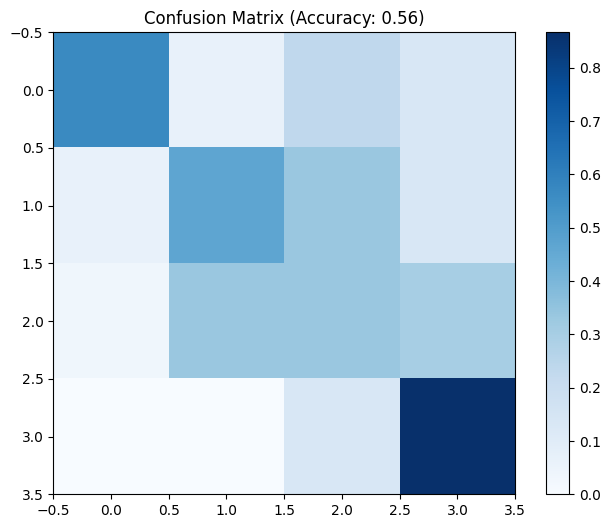

In [9]:
with_tune_param(featStep=20, imsize=255, Nim4training=70, ks=40, num_class=4)


Feature extraction completed in 1.26
Kmeans clustering completed in 27.99
Accuracy: 0.57


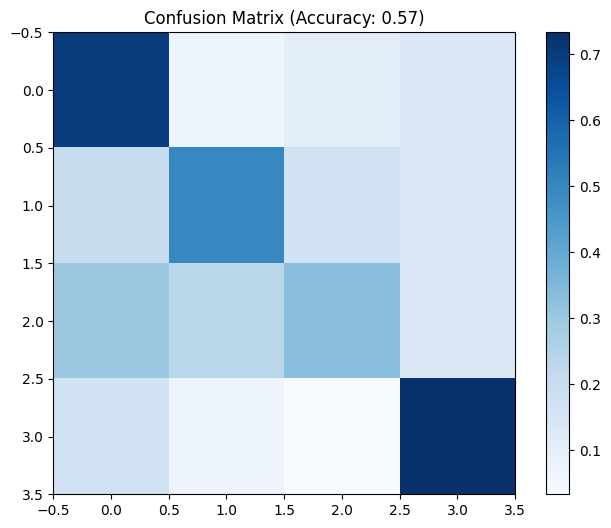

In [10]:
with_tune_param(featStep=8, imsize=128, Nim4training=70, ks=20, num_class=4)

Feature extraction completed in 1.24
Kmeans clustering completed in 11.21
Accuracy: 0.32


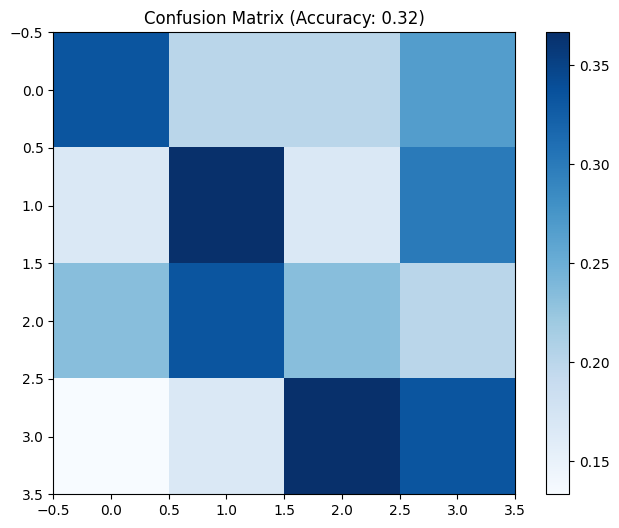

In [12]:
with_tune_param(featStep=16, imsize=128, Nim4training=70, ks=100, num_class=4)


Feature extraction completed in 0.75
Kmeans clustering completed in 9.25
Accuracy: 0.34


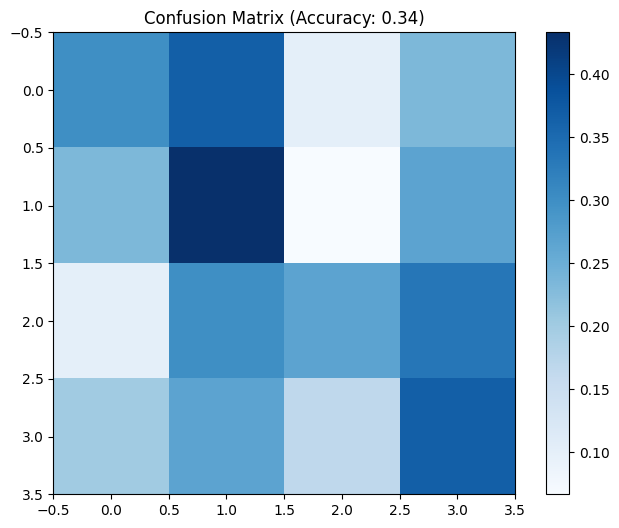

In [13]:
with_tune_param(featStep=16, imsize=128, Nim4training=70, ks=50, num_class=4)


Feature extraction completed in 2.39
Kmeans clustering completed in 51.19
Accuracy: 0.57


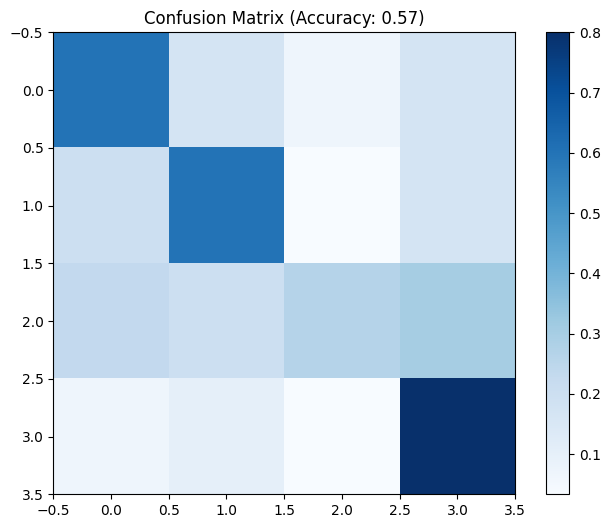

In [14]:
with_tune_param(featStep=20, imsize=255, Nim4training=70, ks=100, num_class=4)


Feature extraction completed in 1.35
Kmeans clustering completed in 47.62
Accuracy: 0.60


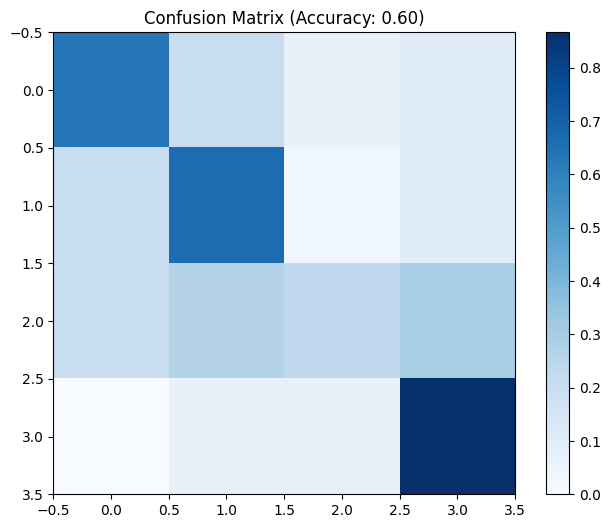

In [15]:
with_tune_param(featStep=20, imsize=332, Nim4training=70, ks=40, num_class=4)

Feature extraction completed in 2.15
Kmeans clustering completed in 107.11
Accuracy: 0.56


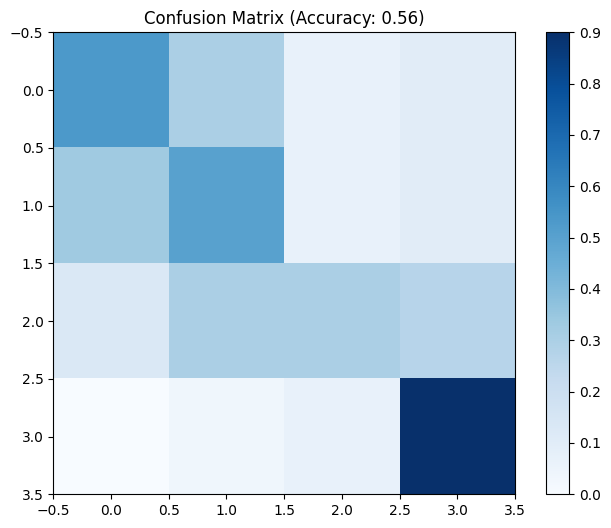

In [16]:
with_tune_param(featStep=20, imsize=332, Nim4training=70, ks=100, num_class=4)

Feature extraction completed in 2.63
Kmeans clustering completed in 321.67
Accuracy: 0.68


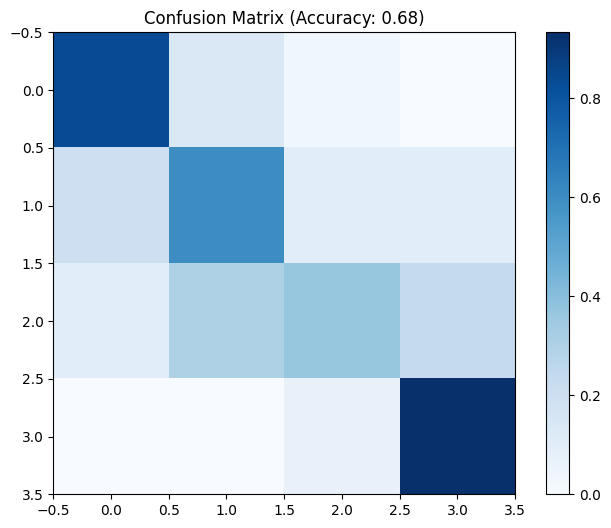

In [18]:
with_tune_param(featStep=20, imsize=500, Nim4training=70, ks=100, num_class=4)


Feature extraction completed in 2.61
Kmeans clustering completed in 395.62
Accuracy: 0.68


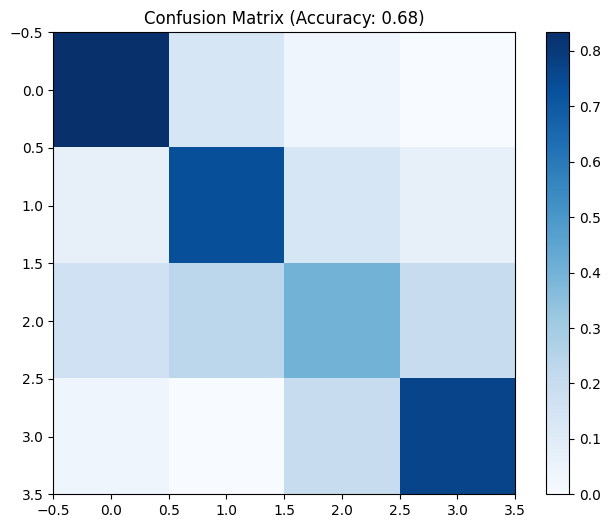

In [17]:
with_tune_param(featStep=20, imsize=500, Nim4training=70, ks=124, num_class=4)


In [ ]:
image_sizes = [64, 128, 255, 332, 332, 500]
featSteps = [8, 16, 20, 20, 20, 20]
Ks = [20, 50, 100, 40, 100, 124]
num_class=4

Assignment 04 Report

1. What I did
I built a pipeline with the following steps:
Resize images
Extract features using dense SIFT
Use K-means to create visual words
Represent each image as a histogram (BoW)
Classify images using 1-Nearest Neighbor (1-NN)
2. Parameter Tuning
I tested different values for:
Image size → [64, 128, 255, 332, 500]
Grid step (featStep) → [8, 16, 20]
Number of centroids (K) → [20, 50, 100, 124]
Number of classes → 4
I tried multiple combinations and compared the accuracy.
3. Best Parameters Found
The best results were obtained with:
Image size = 500
Grid step = 20
Number of centroids (K) = 124
Number of classes = 4
4. Results
Final accuracy = 68%
The confusion matrix is shown in the output plot.
5. Conclusion
The model works reasonably well with 68% accuracy.
The best performance was achieved using larger image size and more centroids.
However, the performance is limited because:
BoW does not use spatial information (the model does not know where features are in the image, so it sometimes confuses similar-looking classes)
SIFT features are not always enough to separate classes
